# Zero-Shot Model Ablation — Combined Results

Pulls all zero-shot (base, no fine-tuning) evaluation runs from the **`eval-all`** W&B project, then compiles a LaTeX table for the paper.

**Benchmarks**: GoldCoin-HIPAA (applicability + compliance), PrivacyLens (QA probing + leakage)

**Expected models** (EXPERIMENTS.md § "Zero-shot baselines"):
Qwen3.5-9B, Llama-3.1-8B-Instruct, Phi-4, Gemma-3-12B-IT, GPT-OSS-20B, Llama-3.3-70B-Instruct, CIRL-7B

In [1]:
import wandb
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display, Latex

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.3f}".format)

# ── Configuration ──────────────────────────────────────────────────────────
WANDB_ENTITY = "uair"
WANDB_PROJECT = "eval-all"

# Display names for models (checkpoint_name → paper label)
MODEL_DISPLAY = {
    "Qwen3.5-2B": "Qwen3.5-2B",
    "Qwen3.5-4B": "Qwen3.5-4B",
    "Qwen3.5-9B": "Qwen3.5-9B",
    "Qwen3.5-27B": "Qwen3.5-27B",
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B",
    "Phi-4": "Phi-4-14B",
    "Gemma-3-12B-IT": "Gemma-3-12B",
    "GPT-OSS-20B": "GPT-OSS-20B",
    "OpenThinker3-7B": "OpenThinker3-7B",
    "OpenThinker-7B": "OpenThinker-7B",
    "context-reasoner-ppo_open_thinker_acc_reward": "ContextReasoner-7B",
    "CIRL": "CIRL-7B",
}

# Desired row order (top to bottom)
MODEL_ORDER = list(MODEL_DISPLAY.values())

api = wandb.Api()
print(f"Connected to W&B entity={WANDB_ENTITY}, project={WANDB_PROJECT}")

Connected to W&B entity=uair, project=eval-all


## 1. Fetch runs from W&B

Each `eval_all` invocation creates child runs per benchmark stage. We filter for `base` (no fine-tuning) runs that logged evaluation metrics.

**Metric keys** (logged by each dagspace orchestrator):
- GoldCoin: `compute_metrics/eval/accuracy`, `compute_metrics/eval/macro_f1` (with `config.eval_task` = applicability|compliance)
- PrivacyLens: `compute_metrics/eval/qa_accuracy`, `compute_metrics/eval/leakage_rate`, `compute_metrics/eval/qa_{axis}_accuracy`

In [2]:
# Fetch all runs from the eval-all project tagged "base"
runs = api.runs(
    f"{WANDB_ENTITY}/{WANDB_PROJECT}",
    filters={"tags": {"$in": ["base"]}},
)
print(f"Found {len(runs)} base-tagged runs")

# Inspect first few runs to understand available keys
for r in runs[:5]:
    print(f"\n  {r.name}  (state={r.state})")
    print(f"    tags: {r.tags}")
    print(f"    config keys: {list(r.config.keys())[:15]}")
    summary_keys = [k for k in r.summary.keys() if "eval" in k or "accuracy" in k or "leakage" in k]
    print(f"    eval summary keys: {summary_keys}")

Found 189 base-tagged runs

  full_eval-goldcoin_hipaa-orchestrator-20260327-203006  (state=finished)
    tags: ['base', 'bench:goldcoin_hipaa', 'family:qwen3.5', 'task:compliance']
    config keys: ['model', 'slurm', 'system', 'runtime', 'compute.cpu_count', 'compute.gpu_count', 'compute.memory_gb', 'compute.cpu_architecture']
    eval summary keys: ['compute_metrics/eval/accuracy', 'compute_metrics/eval/applicable/correct', 'compute_metrics/eval/applicable/error', 'compute_metrics/eval/applicable/f1', 'compute_metrics/eval/applicable/precision', 'compute_metrics/eval/applicable/recall', 'compute_metrics/eval/applicable/support', 'compute_metrics/eval/applicable/total', 'compute_metrics/eval/cm/applicable_pred_applicable', 'compute_metrics/eval/cm/applicable_pred_not_applicable', 'compute_metrics/eval/cm/forbid_pred_forbid', 'compute_metrics/eval/cm/forbid_pred_permit', 'compute_metrics/eval/cm/not_applicable_pred_applicable', 'compute_metrics/eval/cm/not_applicable_pred_not_applicabl

## 2. Extract metrics into a unified DataFrame

Metrics live on **orchestrator runs** (not per-stage runs). These runs:
- Have `checkpoint_name` nested under `config.model` (not top-level)
- Don't have a `stage` key in config
- GoldCoin orchestrator runs contain **both** applicability and compliance metrics in a single run
- PrivacyLens QA axes are uppercase: `qa_S_accuracy`, `qa_V_accuracy`, `qa_T_accuracy`

In [3]:
def extract_run_metrics(run) -> dict | None:
    """Extract structured metrics from a single W&B run.
    
    Metrics live on orchestrator runs. checkpoint_name is nested under config.model.
    GoldCoin runs contain both applicability + compliance metrics in one run.
    Applicability F1 = mean(applicable_f1, not_applicable_f1).
    Compliance F1 = mean(permit_f1, forbid_f1).
    """
    config = run.config
    summary = run.summary
    tags = set(run.tags)
    
    checkpoint = config.get("model", {}).get("checkpoint_name", "")
    if not checkpoint:
        return None
    
    dagspace = None
    for t in tags:
        if t.startswith("bench:"):
            dagspace = t.split(":", 1)[1]
            break
    if not dagspace:
        return None
    
    row = {"checkpoint": checkpoint, "dagspace": dagspace, "run_id": run.id}
    has_metrics = False
    
    if dagspace == "goldcoin_hipaa":
        app_f1 = summary.get("compute_metrics/eval/applicable/f1")
        notapp_f1 = summary.get("compute_metrics/eval/not_applicable/f1")
        permit_f1 = summary.get("compute_metrics/eval/permit/f1")
        forbid_f1 = summary.get("compute_metrics/eval/forbid/f1")
        if app_f1 is not None and notapp_f1 is not None:
            row["gc_applicability_f1"] = (app_f1 + notapp_f1) / 2
            has_metrics = True
        if permit_f1 is not None and forbid_f1 is not None:
            row["gc_compliance_f1"] = (permit_f1 + forbid_f1) / 2
            has_metrics = True
    elif dagspace == "privacylens":
        qa_acc = summary.get("compute_metrics/eval/qa_accuracy")
        leak = summary.get("compute_metrics/eval/leakage_rate")
        adj_leak = summary.get("compute_metrics/eval/adjusted_leakage_rate")
        helpful = summary.get("compute_metrics/eval/helpful_rate")
        if qa_acc is not None or leak is not None:
            row["pl_qa_accuracy"] = qa_acc
            row["pl_leakage_rate"] = leak
            row["pl_adjusted_leakage_rate"] = adj_leak
            row["pl_helpful_rate"] = helpful
            has_metrics = True
    elif dagspace == "vlm_geoprivacy_bench":
        q7_acc = summary.get("compute_metrics/eval/Q7/accuracy")
        if q7_acc is not None:
            row["vlm_q7_accuracy"] = q7_acc
            has_metrics = True
    
    return row if has_metrics else None


rows = []
for r in runs:
    m = extract_run_metrics(r)
    if m is not None:
        rows.append(m)

df_raw = pd.DataFrame(rows)
print(f"Extracted {len(df_raw)} metric rows")
print(f"Models: {sorted(df_raw['checkpoint'].unique())}")
print(f"Benchmarks: {sorted(df_raw['dagspace'].unique())}")
display(df_raw)

Extracted 62 metric rows
Models: ['CIRL', 'GPT-OSS-20B', 'Gemma-3-12B-IT', 'Llama-3.1-8B-Instruct', 'OpenThinker-7B', 'OpenThinker3-7B', 'Phi-4', 'Phi-4-multimodal-instruct', 'Qwen3-8B', 'Qwen3.5-2B', 'Qwen3.5-4B', 'Qwen3.5-9B', 'context-reasoner-ppo_open_thinker_acc_reward']
Benchmarks: ['goldcoin_hipaa', 'privacylens', 'vlm_geoprivacy_bench']


,checkpoint,dagspace,run_id,gc_applicability_f1,gc_compliance_f1,pl_qa_accuracy,pl_leakage_rate,pl_adjusted_leakage_rate,pl_helpful_rate,vlm_q7_accuracy
0,Qwen3.5-2B,goldcoin_hipaa,hr4qetln,0.576,0.586,NaN,NaN,NaN,NaN,NaN
1,Qwen3.5-4B,goldcoin_hipaa,jj77ycjq,0.901,0.731,NaN,NaN,NaN,NaN,NaN
2,Qwen3.5-9B,goldcoin_hipaa,8xb69mrp,0.953,0.704,NaN,NaN,NaN,NaN,NaN
3,Qwen3.5-2B,privacylens,16c1seea,NaN,NaN,0.983,0.116,NaN,NaN,NaN
4,Qwen3.5-4B,privacylens,6h6zp8v4,NaN,NaN,0.903,0.617,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
57,OpenThinker3-7B,privacylens,hwscepq6,NaN,NaN,0.858,0.237,0.271,0.442,NaN
58,OpenThinker-7B,privacylens,woym26c7,NaN,NaN,0.995,0.286,0.286,0.986,NaN
59,context-reasoner-ppo_open_thinker_acc_reward,privacylens,79pmy3sb,NaN,NaN,0.985,0.164,0.306,0.345,NaN
60,CIRL,goldcoin_hipaa,tif7nxgw,0.958,0.533,NaN,NaN,NaN,NaN,NaN


In [4]:
# drop Phi-4-multimodal-instruct
df_raw = df_raw[df_raw['checkpoint'] != 'Phi-4-multimodal-instruct']
print(f"Models: {sorted(df_raw['checkpoint'].unique())}")
print(f"Benchmarks: {sorted(df_raw['dagspace'].unique())}")
display(df_raw)

Models: ['CIRL', 'GPT-OSS-20B', 'Gemma-3-12B-IT', 'Llama-3.1-8B-Instruct', 'OpenThinker-7B', 'OpenThinker3-7B', 'Phi-4', 'Qwen3-8B', 'Qwen3.5-2B', 'Qwen3.5-4B', 'Qwen3.5-9B', 'context-reasoner-ppo_open_thinker_acc_reward']
Benchmarks: ['goldcoin_hipaa', 'privacylens', 'vlm_geoprivacy_bench']


,checkpoint,dagspace,run_id,gc_applicability_f1,gc_compliance_f1,pl_qa_accuracy,pl_leakage_rate,pl_adjusted_leakage_rate,pl_helpful_rate,vlm_q7_accuracy
0,Qwen3.5-2B,goldcoin_hipaa,hr4qetln,0.576,0.586,NaN,NaN,NaN,NaN,NaN
1,Qwen3.5-4B,goldcoin_hipaa,jj77ycjq,0.901,0.731,NaN,NaN,NaN,NaN,NaN
2,Qwen3.5-9B,goldcoin_hipaa,8xb69mrp,0.953,0.704,NaN,NaN,NaN,NaN,NaN
3,Qwen3.5-2B,privacylens,16c1seea,NaN,NaN,0.983,0.116,NaN,NaN,NaN
4,Qwen3.5-4B,privacylens,6h6zp8v4,NaN,NaN,0.903,0.617,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
57,OpenThinker3-7B,privacylens,hwscepq6,NaN,NaN,0.858,0.237,0.271,0.442,NaN
58,OpenThinker-7B,privacylens,woym26c7,NaN,NaN,0.995,0.286,0.286,0.986,NaN
59,context-reasoner-ppo_open_thinker_acc_reward,privacylens,79pmy3sb,NaN,NaN,0.985,0.164,0.306,0.345,NaN
60,CIRL,goldcoin_hipaa,tif7nxgw,0.958,0.533,NaN,NaN,NaN,NaN,NaN


## 3. Pivot into paper table

One row per model. GoldCoin orchestrator runs log both applicability and compliance metrics together. We de-duplicate by checkpoint and merge across benchmarks.

In [5]:
# De-duplicate: keep last run per (checkpoint, dagspace)
df_dedup = df_raw.drop_duplicates(subset=["checkpoint", "dagspace"], keep="last")

# ── GoldCoin: Applicability F1, Compliance F1 ──
gc = df_dedup[df_dedup["dagspace"] == "goldcoin_hipaa"][
    ["checkpoint", "gc_applicability_f1", "gc_compliance_f1"]
].rename(columns={
    "gc_applicability_f1": "App F1",
    "gc_compliance_f1": "Comp F1",
})

# ── PrivacyLens: QA Acc, Adjusted Leakage Rate, Helpful Rate ──
pl_cols = ["checkpoint", "pl_qa_accuracy", "pl_adjusted_leakage_rate", "pl_helpful_rate"]
pl_cols = [c for c in pl_cols if c in df_dedup.columns]
pl = df_dedup[df_dedup["dagspace"] == "privacylens"][pl_cols].rename(columns={
    "pl_qa_accuracy": "QA Acc",
    "pl_adjusted_leakage_rate": "Adj Leak",
    "pl_helpful_rate": "Helpful",
})

# ── VLM-GeoPrivacy: Q7 Acc ──
vlm = df_dedup[df_dedup["dagspace"] == "vlm_geoprivacy_bench"][
    ["checkpoint", "vlm_q7_accuracy"]
].rename(columns={
    "vlm_q7_accuracy": "Q7 Acc",
})

# ── Merge on checkpoint ──
df_table = gc.merge(pl, on="checkpoint", how="outer") \
              .merge(vlm, on="checkpoint", how="outer")

# Map to display names and reorder
df_table["Model"] = df_table["checkpoint"].map(MODEL_DISPLAY).fillna(df_table["checkpoint"])
df_table = df_table.set_index("Model").drop(columns=["checkpoint"])

idx = [m for m in MODEL_ORDER if m in df_table.index]
extra = [m for m in df_table.index if m not in MODEL_ORDER]
df_table = df_table.loc[idx + extra]

# Convert [0,1] to percentage
for c in df_table.columns:
    df_table[c] = df_table[c] * 100

display(df_table.round(2))

,App F1,Comp F1,QA Acc,Adj Leak,Helpful,Q7 Acc
Model,,,,,,
Qwen3.5-2B,56.890,58.600,98.310,26.900,69.370,21.200
Qwen3.5-4B,90.110,72.210,90.470,27.730,89.250,51.210
Qwen3.5-9B,95.320,72.350,95.330,22.420,90.470,63.470
Llama-3.1-8B,92.060,61.010,97.430,28.160,62.680,NaN
Phi-4-14B,96.260,66.980,97.030,20.520,93.910,NaN
Gemma-3-12B,94.380,74.350,98.380,27.270,89.250,40.740
GPT-OSS-20B,77.330,65.320,89.590,12.110,92.090,NaN
OpenThinker3-7B,77.020,15.750,85.800,27.060,44.220,NaN
OpenThinker-7B,92.980,67.420,99.460,28.600,98.580,NaN


## 4. Generate LaTeX table

Produces a `booktabs`-style table suitable for direct inclusion in the paper.

In [6]:
def build_latex_table(df: pd.DataFrame) -> str:
    """Generate a booktabs LaTeX table from the pivoted DataFrame."""
    
    gc_cols = ["App F1", "Comp F1"]
    pl_cols = ["QA Acc", "Adj Leak", "Helpful"]
    vlm_cols = ["Q7 Acc"]
    all_cols = [c for c in gc_cols + pl_cols + vlm_cols if c in df.columns and df[c].notna().any()]
    
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"\centering")
    lines.append(r"\caption{Zero-shot baseline performance across CI benchmarks (\%). "
                 r"Adj Leak = leakage among helpful responses only. "
                 r"$\downarrow$ = lower is better.}")
    lines.append(r"\label{tab:zero-shot-ablation}")
    lines.append(r"\begin{tabular}{l" + "c" * len(all_cols) + "}")
    lines.append(r"\toprule")
    
    # Header row 1: benchmark groups
    gc_present = [c for c in gc_cols if c in all_cols]
    pl_present = [c for c in pl_cols if c in all_cols]
    vlm_present = [c for c in vlm_cols if c in all_cols]
    
    group_header = " "
    col_idx = 2
    cmidrules = []
    if gc_present:
        group_header += rf" & \multicolumn{{{len(gc_present)}}}{{c}}{{\textbf{{GoldCoin-HIPAA}}}}"
        cmidrules.append(rf"\cmidrule(lr){{{col_idx}-{col_idx + len(gc_present) - 1}}}")
        col_idx += len(gc_present)
    if pl_present:
        group_header += rf" & \multicolumn{{{len(pl_present)}}}{{c}}{{\textbf{{PrivacyLens}}}}"
        cmidrules.append(rf"\cmidrule(lr){{{col_idx}-{col_idx + len(pl_present) - 1}}}")
        col_idx += len(pl_present)
    if vlm_present:
        group_header += rf" & \multicolumn{{{len(vlm_present)}}}{{c}}{{\textbf{{VLM-GeoPri.}}}}"
        cmidrules.append(rf"\cmidrule(lr){{{col_idx}-{col_idx + len(vlm_present) - 1}}}")
    
    lines.append(group_header + r" \\")
    lines.append(" ".join(cmidrules))
    
    # Header row 2
    col_labels = {
        "App F1": r"App F1",
        "Comp F1": r"Comp F1",
        "QA Acc": r"QA Acc",
        "Adj Leak": r"Adj Leak $\downarrow$",
        "Helpful": r"Helpful",
        "Q7 Acc": r"Q7 Acc",
    }
    col_headers = [r"\textbf{Model}"] + [col_labels.get(c, c) for c in all_cols]
    lines.append(" & ".join(col_headers) + r" \\")
    lines.append(r"\midrule")
    
    # Bold best per column
    lower_better = {"Adj Leak"}
    best = {}
    for col in all_cols:
        vals = df[col].dropna()
        if len(vals) == 0:
            continue
        best[col] = vals.min() if col in lower_better else vals.max()
    
    for model_name, row in df.iterrows():
        cells = [str(model_name)]
        for col in all_cols:
            val = row.get(col, np.nan)
            txt = "---" if pd.isna(val) else f"{val:.1f}"
            if col in best and not pd.isna(val) and val == best[col]:
                txt = rf"\textbf{{{txt}}}"
            cells.append(txt)
        lines.append(" & ".join(cells) + r" \\")
    
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")
    
    return "\n".join(lines)


latex = build_latex_table(df_table)
print(latex)

\begin{table}[t]
\centering
\caption{Zero-shot baseline performance across CI benchmarks (\%). Adj Leak = leakage among helpful responses only. $\downarrow$ = lower is better.}
\label{tab:zero-shot-ablation}
\begin{tabular}{lcccccc}
\toprule
  & \multicolumn{2}{c}{\textbf{GoldCoin-HIPAA}} & \multicolumn{3}{c}{\textbf{PrivacyLens}} & \multicolumn{1}{c}{\textbf{VLM-GeoPri.}} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-6} \cmidrule(lr){7-7}
\textbf{Model} & App F1 & Comp F1 & QA Acc & Adj Leak $\downarrow$ & Helpful & Q7 Acc \\
\midrule
Qwen3.5-2B & 56.9 & 58.6 & 98.3 & 26.9 & 69.4 & 21.2 \\
Qwen3.5-4B & 90.1 & 72.2 & 90.5 & 27.7 & 89.2 & 51.2 \\
Qwen3.5-9B & 95.3 & 72.4 & 95.3 & 22.4 & 90.5 & \textbf{63.5} \\
Llama-3.1-8B & 92.1 & 61.0 & 97.4 & 28.2 & 62.7 & --- \\
Phi-4-14B & \textbf{96.3} & 67.0 & 97.0 & 20.5 & 93.9 & --- \\
Gemma-3-12B & 94.4 & \textbf{74.4} & 98.4 & 27.3 & 89.2 & 40.7 \\
GPT-OSS-20B & 77.3 & 65.3 & 89.6 & \textbf{12.1} & 92.1 & --- \\
OpenThinker3-7B & 77.0 & 15.8 & 85.8 &

## 5. Save to .tex file

In [7]:
out_dir = Path("tables")
out_dir.mkdir(exist_ok=True)
out_path = out_dir / "zero_shot_ablation.tex"
out_path.write_text(latex)
print(f"Saved to {out_path.resolve()}")

Saved to /share/pierson/matt/UAIR/notebooks/COLM26/tables/zero_shot_ablation.tex


## 6. Comparative bar plots

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7.5,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.25,
    "grid.linewidth": 0.5,
})

# Qualitative palette (colorblind-friendly, muted for print)
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"]

def _model_colors(models):
    """Map model names to consistent colors."""
    return {m: PALETTE[i % len(PALETTE)] for i, m in enumerate(models)}

models = list(df_table.index)
colors = _model_colors(models)
print(f"Plotting {len(models)} models: {models}")

Plotting 12 models: ['Qwen3.5-2B', 'Qwen3.5-4B', 'Qwen3.5-9B', 'Llama-3.1-8B', 'Phi-4-14B', 'Gemma-3-12B', 'GPT-OSS-20B', 'OpenThinker3-7B', 'OpenThinker-7B', 'ContextReasoner-7B', 'CIRL-7B', 'Qwen3-8B']


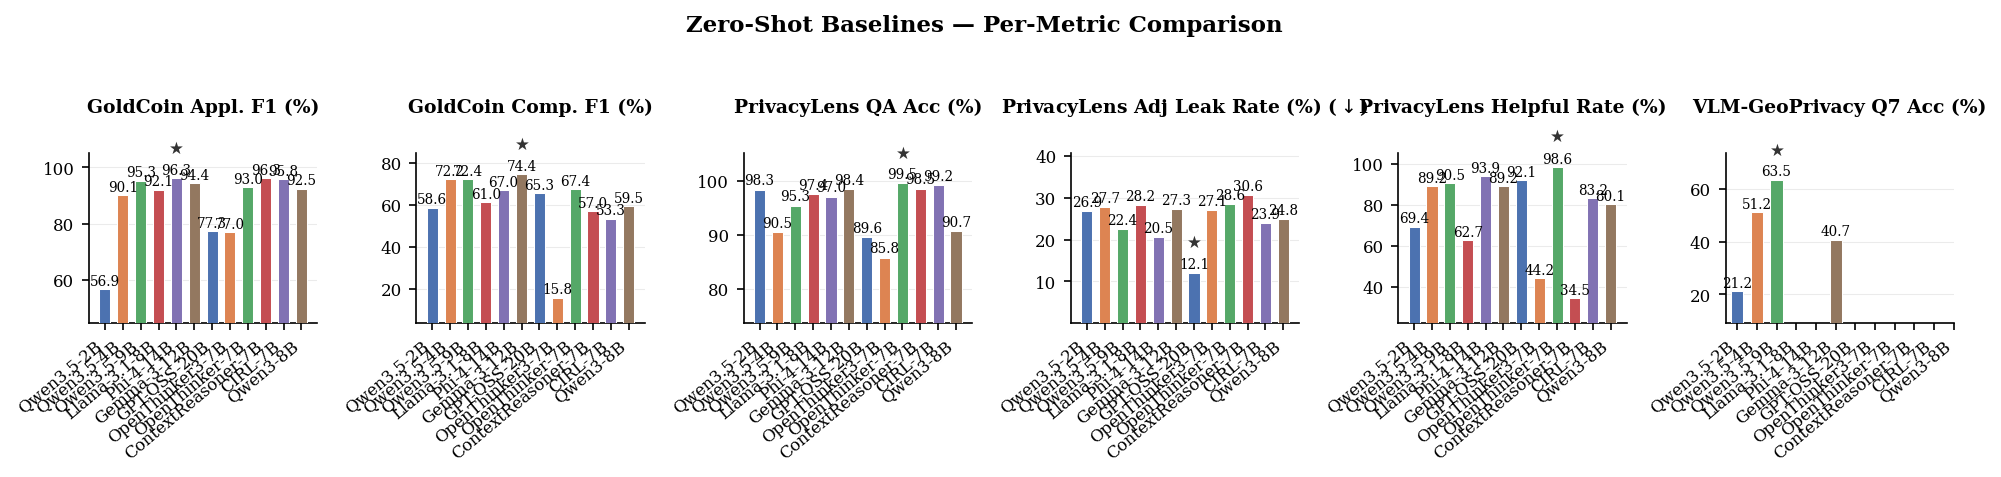

In [9]:
# ── Figure 1: Per-benchmark bar charts (one panel per metric) ──────────────

metric_spec = [
    ("App F1",    "GoldCoin Appl. F1 (%)",          True),
    ("Comp F1",   "GoldCoin Comp. F1 (%)",          True),
    ("QA Acc",    "PrivacyLens QA Acc (%)",          True),
    ("Adj Leak",  "PrivacyLens Adj Leak Rate (%)",   False),  # lower is better
    ("Helpful",   "PrivacyLens Helpful Rate (%)",    True),
    ("Q7 Acc",    "VLM-GeoPrivacy Q7 Acc (%)",       True),
]
# Keep only metrics with data
metric_spec = [(col, label, hb) for col, label, hb in metric_spec
               if col in df_table.columns and df_table[col].notna().any()]

n = len(metric_spec)
fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 3), squeeze=False)
axes = axes[0]

for ax, (col, label, higher_better) in zip(axes, metric_spec):
    vals = df_table[col].reindex(models)
    bar_colors = [colors[m] for m in models]
    bars = ax.bar(range(len(models)), vals, color=bar_colors, width=0.62,
                   edgecolor="white", linewidth=0.5, zorder=3)

    # Annotate values
    for bar, v in zip(bars, vals):
        if pd.notna(v):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.4,
                    f"{v:.1f}", ha="center", va="bottom",
                    fontsize=6.5, fontweight="medium")

    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=40, ha="right")
    suffix = "" if higher_better else r" ($\downarrow$)"
    ax.set_title(label + suffix, fontsize=9, fontweight="bold", pad=20)

    # y-axis range
    valid = vals.dropna()
    if len(valid):
        lo = max(0, valid.min() - 12)
        hi = min(valid.max() + 10, 105)
        ax.set_ylim(lo, hi)

    # Highlight best bar with a star
    if len(valid):
        best_val = valid.min() if not higher_better else valid.max()
        best_idx = vals.tolist().index(best_val)
        ax.annotate("$\\bigstar$",
                    xy=(best_idx, best_val),
                    xytext=(0, 12), textcoords="offset points",
                    ha="center", fontsize=8, color="#333333")

fig.suptitle("Zero-Shot Baselines — Per-Metric Comparison",
             fontsize=11, fontweight="bold", y=1.04)
plt.tight_layout()
fig.savefig("tables/zero_shot_per_metric.pdf")
plt.show()

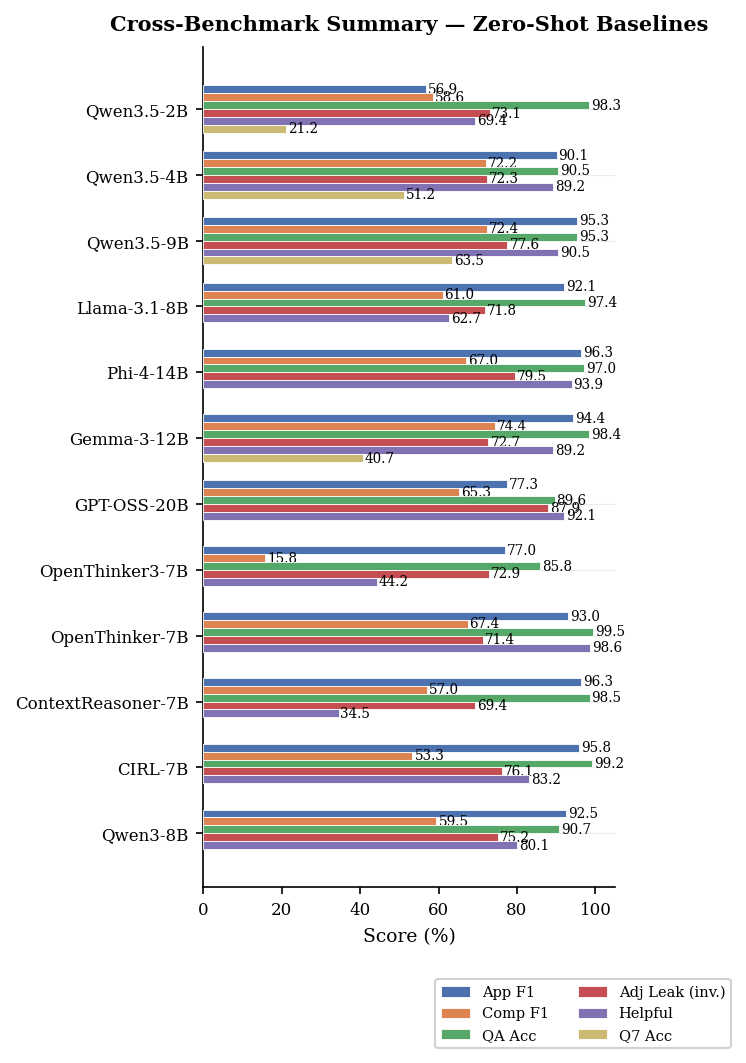

In [10]:
# ── Figure 2: Cross-benchmark horizontal grouped bars ──────────────────────
# One row per model, one bar per metric. Adj Leak inverted (100 - rate) so
# higher = better everywhere for visual consistency.

summary_metrics = {
    "App F1":          ("App F1",    False),
    "Comp F1":         ("Comp F1",   False),
    "QA Acc":          ("QA Acc",    False),
    "Adj Leak (inv.)": ("Adj Leak",  True),   # invert
    "Helpful":         ("Helpful",   False),
    "Q7 Acc":          ("Q7 Acc",    False),
}
summary_metrics = {k: v for k, v in summary_metrics.items()
                   if v[0] in df_table.columns and df_table[v[0]].notna().any()}

n_metrics = len(summary_metrics)
n_models = len(models)
bar_h = 0.72 / n_metrics
y = np.arange(n_models)
metric_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#CCB974"]

fig, ax = plt.subplots(figsize=(5.5, 0.52 * n_models + 0.9))

for j, (disp_label, (col, invert)) in enumerate(summary_metrics.items()):
    offset = (j - (n_metrics - 1) / 2) * bar_h
    vals = df_table[col].reindex(models).values.copy()
    if invert:
        vals = np.where(np.isnan(vals), np.nan, 100 - vals)
    bars = ax.barh(y + offset, vals, bar_h, label=disp_label,
                   color=metric_colors[j % len(metric_colors)],
                   edgecolor="white", linewidth=0.4, zorder=3)
    for bar, v in zip(bars, vals):
        if pd.notna(v) and v > 0:
            ax.text(bar.get_width() + 0.5,
                    bar.get_y() + bar.get_height() / 2,
                    f"{v:.1f}", ha="left", va="center", fontsize=6.5)

ax.set_yticks(y)
ax.set_yticklabels(models, fontsize=8)
ax.set_xlabel("Score (%)")
ax.set_xlim(0, 105)
ax.xaxis.set_major_locator(mticker.MultipleLocator(20))
ax.legend(loc="lower right", framealpha=0.9, ncol=2, fontsize=7, bbox_to_anchor=(1.3, -0.2))
ax.set_title("Cross-Benchmark Summary — Zero-Shot Baselines",
             fontsize=10, fontweight="bold", pad=8)
ax.invert_yaxis()

plt.tight_layout()
fig.savefig("tables/zero_shot_cross_benchmark.pdf")
plt.show()